<a href="https://colab.research.google.com/github/nguyenanhthu000000/Machine-learning/blob/main/02.%20Logistic_Regression/NguyenAnhThu_2474802010381_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#-*- coding: utf-8 -*-
"""Bước 1: đọc bộ dữ liệu sinh viên và xem qua một lượt."""

import pandas as pd

df = pd.read_csv("sinh_vien.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

# Cột qua_mon chỉ có hai giá trị, đếm số lần xuất hiện từng giá trị
print("So sinh vien theo ket qua:")
print(df["qua_mon"].value_counts())
print()

print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print()

# So sánh số giờ ôn trung bình của hai nhóm
print("So gio on trung binh theo nhom:")
print(df.groupby("qua_mon")["gio_on"].mean().round(2))

In [ ]:
#-*- coding: utf-8 -*-
"""Bước 2: làm quen hàm sigmoid bằng tay trước khi gọi thư viện."""

import numpy as np


def sigmoid(z):
    """Ep mot so thuc bat ky ve khoang tu 0 toi 1."""
    return 1 / (1 + np.exp(-z))


print("Bang gia tri cua ham sigmoid")
print("  z    sigmoid(z)")
for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
    print(f"{z:3d}    {sigmoid(z):.4f}")
print()

# Hai tính chất cần tự kiểm chứng
print("Kiem tra sigmoid(-z) = 1 - sigmoid(z):")
for z in [1.0, 2.5, 3.7]:
    trai = sigmoid(-z)
    phai = 1 - sigmoid(z)
    print(f"  z={z}: {trai:.6f} va {phai:.6f}")
print()

# Thử với một mô hình giả định w=0.4 và b=-5
w, b = 0.4, -5.0
print(f"Mo hinh gia dinh: w={w}, b={b}")
print("  So gio on    z=w*x+b    Xac suat qua mon")
for gio in [5, 10, 12.5, 15, 20, 25]:
    z = w * gio + b
    print(f"   {gio:5.1f}        {z:6.2f}          {sigmoid(z):.4f}")

In [ ]:
#-*- coding: utf-8 -*-
"""Bước 3: để scikit-learn tìm w và b từ dữ liệu thật."""

import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("sinh_vien.csv")

# X phải là bảng hai chiều nên viết hai cặp ngoặc vuông.
# y là dãy một chiều nên chỉ một cặp.
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()

# Số giờ ôn mà mô hình phân vân đúng năm mươi năm mươi
print(f"So gio on ung voi xac suat 0.5: {-b/w:.2f} gio")
print()

can_moi = pd.DataFrame({"gio_on": [5.0, 10.0, 13.0, 20.0, 28.0]})
xac_suat = mo_hinh.predict_proba(can_moi)[:, 1]
nhan = mo_hinh.predict(can_moi)

print("Du doan cho nam ban moi:")
print("  So gio on    Xac suat qua    Nhan mo hinh dua ra")
for gio, p, n in zip(can_moi["gio_on"], xac_suat, nhan):
    print(f"   {gio:5.1f}          {p:.4f}                 {n}")

In [ ]:
#-*- coding: utf-8 -*-
"""Bước 4: chia dữ liệu rồi chấm điểm mô hình bằng bốn thước đo."""

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

# stratify=y giữ đúng tỷ lệ qua và rớt ở cả hai phần sau khi chia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

print("So sinh vien de hoc  :", len(X_train))
print("So sinh vien de kiem tra:", len(X_test))
print()

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)

# Thứ tự bốn ô do scikit-learn quy định là TN, FP, FN, TP
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Ma tran nham lan")
print(f"  TN = {tn:2d} doan rot, that su rot")
print(f"  FP = {fp:2d} doan qua, that ra rot")
print(f"  FN = {fn:2d} doan rot, that ra qua")
print(f"  TP = {tp:2d} doan qua, that su qua")
print()

print(f"Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred):.4f}")
print(f"F1        = {f1_score(y_test, y_pred):.4f}")
print()

# Tự tính lại bằng tay để đối chiếu với thư viện
print("Tu tinh lai bang cong thuc:")
n = len(y_test)
print(f"  Accuracy  = ({tp} + {tn}) / {n} = {(tp + tn) / n:.4f}")
print(f"  Precision = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f}")
print(f"  Recall    = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.4f}")

So sinh vien de hoc  : 90
So sinh vien de kiem tra: 30

Ma tran nham lan
  TN =  9 doan rot, that su rot
  FP =  3 doan qua, that ra rot
  FN =  1 doan rot, that ra qua
  TP = 17 doan qua, that su qua

Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947

Tu tinh lai bang cong thuc:
  Accuracy  = (17 + 9) / 30 = 0.8667
  Precision = 17 / (17 + 3) = 0.8500
  Recall    = 17 / (17 + 1) = 0.9444


In [ ]:
#-*- coding: utf-8 -*-
"""Bước 5: tự áp ngưỡng và xem precision với recall đổi ra sao."""

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
p = mo_hinh.predict_proba(X_test)[:, 1]

nguong_list = np.arange(0.05, 1.0, 0.05)
best_nguong = None
best_f1 = -1.0

print("Nguong      F1-score")
for nguong in nguong_list:
    y_pred = (p >= nguong).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f" {nguong:.2f}        {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_nguong = nguong

print()
print(f"Nguong cho F1 cao nhat: {best_nguong:.2f} voi F1 = {best_f1:.4f}")
print()
print("Nhan xet: Nguong tot nhat theo F1 khong nhat thiet phai bang 0.5. Tuy thuoc vao phan bo xac suat va su can bang giua precision va recall, nguong toi uu F1 co the xê dich sang cac gia tri khac.")

Nguong      F1-score
--------------------
 0.05        0.7826
 0.10        0.8182
 0.15        0.8182
 0.20        0.8571
 0.25        0.9000
 0.30        0.8947
 0.35        0.8947
 0.40        0.8947
 0.45        0.8947
 0.50        0.8947
 0.55        0.8889
 0.60        0.9412
 0.65        0.9412
 0.70        0.9091
 0.75        0.8750
 0.80        0.8387
 0.85        0.8000
 0.90        0.5600
 0.95        0.4348

Nguong cho F1 cao nhat: 0.60 voi F1 = 0.9412

Nhan xet: Nguong tot nhat theo F1 khong nhat thiet phai bang 0.5. Tuy thuoc vao phan bo xac suat va su can bang giua precision va recall, nguong toi uu F1 co the xê dich sang cac gia tri khac.


In [ ]:
"""Bước 6: thêm điểm giữa kỳ làm biến thứ hai"""
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
y = df["qua_mon"]

for ten, cot in [("Mot bien", ["gio_on"]), ("Hai bien", ["gio_on", "diem_giua_ky"])]:
    X = df[cot]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=17, stratify=y
    )
    mo_hinh = LogisticRegression().fit(X_train, y_train)
    do_chinh_xac = accuracy_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: accuracy tren tap kiem tra = {do_chinh_xac:.4f}")

print()

X = df[["gio_on", "diem_giua_ky"]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X.columns, mo_hinh.coef_[0]):
    print(f"  {ten_cot:14s} {he_so:+.4f}")
print(f"  {'he so chan':14s} {mo_hinh.intercept_[0]:+.4f}")

print()
print("Ca hai he so deu duong, nghia la on nhieu hon va")
print("diem giua ky cao hon deu lam tang xac suat qua mon.")

Mot bien: accuracy tren tap kiem tra = 0.8667
Hai bien: accuracy tren tap kiem tra = 0.9000

He so cua tung bien:
  gio_on         +0.3035
  diem_giua_ky   +0.5885
  he so chan     -6.9811

Ca hai he so deu duong, nghia la on nhieu hon va
diem giua ky cao hon deu lam tang xac suat qua mon.


In [ ]:
"""Bài 1: thông kê theo nhóm"""
import pandas as pd

df = pd.read_csv("sinh_vien.csv")

nhom_cao = df[df["diem_giua_ky"] >= 7]
nhom_thap = df[df["diem_giua_ky"] < 7]

so_luong_nhom_cao = len(nhom_cao)


ty_le_nhom_cao = nhom_cao["qua_mon"].mean()
ty_le_nhom_thap = nhom_thap["qua_mon"].mean()

print(f"Số sinh viên có điểm giữa kỳ >= 7: {so_luong_nhom_cao}")
print(f"Tỷ lệ qua môn nhóm điểm >= 7: {ty_le_nhom_cao:.4f} ({ty_le_nhom_cao * 100:.2f}%)")
print(f"Tỷ lệ qua môn nhóm điểm < 7: {ty_le_nhom_thap:.4f} ({ty_le_nhom_thap * 100:.2f}%)")
print("\nNhận xét: Điểm giữa kỳ phân biệt rất rõ hai nhóm, sinh viên có điểm giữa kỳ từ 7 trở lên có tỷ lệ qua môn cao hơn hẳn.")

Số sinh viên có điểm giữa kỳ >= 7: 31
Tỷ lệ qua môn nhóm điểm >= 7: 0.9032 (90.32%)
Tỷ lệ qua môn nhóm điểm < 7: 0.4831 (48.31%)

Nhận xét: Điểm giữa kỳ phân biệt rất rõ hai nhóm, sinh viên có điểm giữa kỳ từ 7 trở lên có tỷ lệ qua môn cao hơn hẳn.


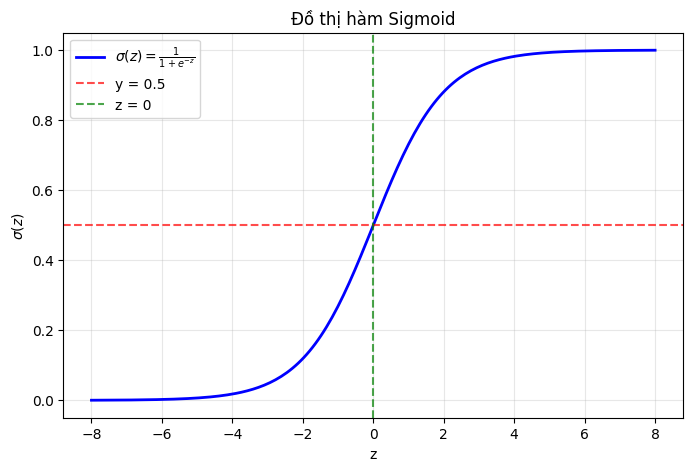

Đã lưu đồ thị vào tệp sigmoid.png trên Colab!


In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)
sig = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, sig, label=r"$\sigma(z) = \frac{1}{1 + e^{-z}}$", color="blue", linewidth=2)
plt.axhline(y=0.5, color="red", linestyle="--", alpha=0.7, label="y = 0.5")
plt.axvline(x=0, color="green", linestyle="--", alpha=0.7, label="z = 0")

plt.title("Đồ thị hàm Sigmoid")
plt.xlabel("z")
plt.ylabel(r"$\sigma(z)$")
plt.grid(True, alpha=0.3)
plt.legend()

# Lưu tệp ở thư mục hiện tại của Colab
plt.savefig("sigmoid.png")
plt.show()
print("Đã lưu đồ thị vào tệp sigmoid.png trên Colab!")

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

def du_doan(gio):
    z = w * gio + b
    df_gio = pd.DataFrame({"gio_on": [gio]})
    p = float(mo_hinh.predict_proba(df_gio)[0, 1])
    c = 1 if p >= 0.5 else 0
    print(f"Số giờ ôn: {gio:5.2f} | z = {z:7.4f} | Xác suất qua môn: {p:.4f} | Nhãn: {c}")

print("Kết quả dự đoán:")
for gio in [3, 8, 12.89, 18, 26]:
    du_doan(gio)

print("\nGiải thích: Với 12.89 giờ, xác suất ra gần đúng 0.5 vì 12.89 giờ là nghiệm của z = w*x + b = 0 (x = -b/w). Khi z = 0 thì sigmoid(0) = 0.5.")

Kết quả dự đoán:
Số giờ ôn:  3.00 | z = -3.8864 | Xác suất qua môn: 0.0201 | Nhãn: 0
Số giờ ôn:  8.00 | z = -1.9223 | Xác suất qua môn: 0.1276 | Nhãn: 0
Số giờ ôn: 12.89 | z = -0.0015 | Xác suất qua môn: 0.4996 | Nhãn: 0
Số giờ ôn: 18.00 | z =  2.0059 | Xác suất qua môn: 0.8814 | Nhãn: 1
Số giờ ôn: 26.00 | z =  5.1484 | Xác suất qua môn: 0.9942 | Nhãn: 1

Giải thích: Với 12.89 giờ, xác suất ra gần đúng 0.5 vì 12.89 giờ là nghiệm của z = w*x + b = 0 (x = -b/w). Khi z = 0 thì sigmoid(0) = 0.5.


In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

n = len(y_test)
accuracy = (tp + tn) / n
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print("Ma trận nhầm lẫn:")
print(f"  TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}\n")

print("Tự tính bằng công thức:")
print(f"Accuracy  = ({tp} + {tn}) / {n} = {accuracy:.4f}")
print(f"Precision = {tp} / ({tp} + {fp}) = {precision:.4f}")
print(f"Recall    = {tp} / ({tp} + {fn}) = {recall:.4f}")
print(f"F1        = {f1:.4f}")

Ma trận nhầm lẫn:
  TN = 9, FP = 3, FN = 1, TP = 17

Tự tính bằng công thức:
Accuracy  = (17 + 9) / 30 = 0.8667
Precision = 17 / (17 + 3) = 0.8500
Recall    = 17 / (17 + 1) = 0.9444
F1        = 0.8947


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
p = mo_hinh.predict_proba(X_test)[:, 1]

nguong_list = np.arange(0.05, 1.0, 0.05)
best_f1 = -1
best_nguong = None

print("Ngưỡng    F1-Score")
print("-" * 18)
for nguong in nguong_list:
    y_pred = (p >= nguong).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f"{nguong:6.2f}    {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_nguong = nguong

print("-" * 18)
print(f"Ngưỡng cho F1 cao nhất: {best_nguong:.2f} (F1 = {best_f1:.4f})")
print("\nNhận xét: Ngưỡng tốt nhất theo F1 không nhất thiết phải bằng 0.5 (các ngưỡng từ 0.30 đến 0.50 đều đạt F1 tối ưu là 0.8947).")

Ngưỡng    F1-Score
------------------
  0.05    0.7826
  0.10    0.8182
  0.15    0.8182
  0.20    0.8571
  0.25    0.9000
  0.30    0.8947
  0.35    0.8947
  0.40    0.8947
  0.45    0.8947
  0.50    0.8947
  0.55    0.8889
  0.60    0.9412
  0.65    0.9412
  0.70    0.9091
  0.75    0.8750
  0.80    0.8387
  0.85    0.8000
  0.90    0.5600
  0.95    0.4348
------------------
Ngưỡng cho F1 cao nhất: 0.60 (F1 = 0.9412)

Nhận xét: Ngưỡng tốt nhất theo F1 không nhất thiết phải bằng 0.5 (các ngưỡng từ 0.30 đến 0.50 đều đạt F1 tối ưu là 0.8947).


In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

pre_0 = precision_score(y_test, y_pred, pos_label=0)
rec_0 = recall_score(y_test, y_pred, pos_label=0)

pre_1 = precision_score(y_test, y_pred, pos_label=1)
rec_1 = recall_score(y_test, y_pred, pos_label=1)

print("--- KẾT QUẢ KHI ĐỔI LỚP DƯƠNG ---")
print(f"Lớp 0 (Rớt môn): Precision = {pre_0:.4f} | Recall = {rec_0:.4f}")
print(f"Lớp 1 (Qua môn): Precision = {pre_1:.4f} | Recall = {rec_1:.4f}")
print("\nGiải thích:")
print("- Hai bộ số khác nhau vì Precision và Recall được tính dựa trên lớp được chỉ định là 'positive'. Khi hoán đổi lớp dương từ 1 sang 0, vị trí của TP/TN và FP/FN trong công thức bị đảo ngược cho nhau.")

--- KẾT QUẢ KHI ĐỔI LỚP DƯƠNG ---
Lớp 0 (Rớt môn): Precision = 0.9000 | Recall = 0.7500
Lớp 1 (Qua môn): Precision = 0.8500 | Recall = 0.9444

Giải thích:
- Hai bộ số khác nhau vì Precision và Recall được tính dựa trên lớp được chỉ định là 'positive'. Khi hoán đổi lớp dương từ 1 sang 0, vị trí của TP/TN và FP/FN trong công thức bị đảo ngược cho nhau.
